# Exploratory Data Analysis (EDA)

### Research Question

> For San Francisco from 2023 to 2025, did the expansion of Waymo's driverless ride-hailing service correspond with changes in taxi activity, public transit ridership, and the broader transportation market?

### Goal of this notebook

This notebook explores the final transportation dataset and examines relationships between Waymo expansion, taxi activity, public transit ridership, and airport ground transportation activity in San Francisco.

The analysis focuses on identifying patterns, trends, and potential relationships that may help explain whether Waymo's growth corresponded with changes in the local transportation market.

The analyses included in this notebook are:

1. Dataset overview and summary statistics
2. Missing data analysis
3. Waymo growth over time
4. Taxi activity trends
5. Muni ridership trends
6. Correlation analysis
7. Relationship between Waymo activity and public transit demand

The dataset analyzed in this notebook is:

`data/02-processed/final_transportation_monthly.csv`

---

### Key Waymo Expansion Dates Used in This Analysis

- **August 2023** — Waymo launches commercial driverless service to the general public in San Francisco.
- **June 2024** — Waymo One expands service availability to all riders in San Francisco.

# Import Packages

The following packages are used for data manipulation, visualization, and exploratory data analysis throughout this notebook.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

pd.set_option('display.max_columns', None)

# Load Dataset

The final cleaned transportation dataset is loaded for exploratory analysis.

In [2]:
df = pd.read_csv(
    "data/02-processed/final_transportation_monthly.csv"
)

df.head()

,month,waymo_passenger_miles,taxi_trips,taxi_total_fare,taxi_avg_fare,muni_monthly_boardings,muni_recovery_rate,sfo_ground_trips,post_waymo_public_launch,post_waymo_open_to_all,time_trend,waymo_pct_change,taxi_pct_change,muni_pct_change,log_waymo_passenger_miles,log_taxi_trips,log_muni_monthly_boardings
0,2023-01,30308.620,212798.0,6636580.34,31.187231,10662000.0,0.629412,754556.0,0,0,0,NaN,NaN,NaN,10.319220,12.268103,16.182197
1,2023-02,20492.771,189659.0,5741866.64,30.274686,10645000.0,0.662500,694951.0,0,0,1,-32.386328,-10.873692,-0.159445,9.927876,12.152988,16.180601
2,2023-03,22891.252,208091.0,6407863.35,30.793563,11854000.0,0.676136,864610.0,0,0,2,11.704035,9.718495,11.357445,10.038554,12.245736,16.288176
3,2023-04,25934.950,218564.0,6557043.88,30.000567,12189000.0,0.681564,847180.0,0,0,3,13.296337,5.032894,2.826050,10.163385,12.294839,16.316045
4,2023-05,26214.812,209450.0,6354017.79,30.336681,12605000.0,0.692308,961195.0,0,0,4,1.079092,-4.169946,3.412913,10.174118,12.252245,16.349604


# Dataset Overview

The final dataset contains monthly transportation activity in San Francisco from January 2023 to December 2025.

In [3]:
print(df.shape)

df.info()

(36, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   month                       36 non-null     object 
 1   waymo_passenger_miles       36 non-null     float64
 2   taxi_trips                  17 non-null     float64
 3   taxi_total_fare             17 non-null     float64
 4   taxi_avg_fare               17 non-null     float64
 5   muni_monthly_boardings      36 non-null     float64
 6   muni_recovery_rate          36 non-null     float64
 7   sfo_ground_trips            36 non-null     float64
 8   post_waymo_public_launch    36 non-null     int64  
 9   post_waymo_open_to_all      36 non-null     int64  
 10  time_trend                  36 non-null     int64  
 11  waymo_pct_change            35 non-null     float64
 12  taxi_pct_change             16 non-null     float64
 13  muni_pct_change             

In [4]:
df.describe()

,waymo_passenger_miles,taxi_trips,taxi_total_fare,taxi_avg_fare,muni_monthly_boardings,muni_recovery_rate,sfo_ground_trips,post_waymo_public_launch,post_waymo_open_to_all,time_trend,waymo_pct_change,taxi_pct_change,muni_pct_change,log_waymo_passenger_miles,log_taxi_trips,log_muni_monthly_boardings
count,3.600000e+01,17.000000,1.700000e+01,17.000000,3.600000e+01,36.000000,3.600000e+01,36.000000,36.000000,36.000000,35.000000,16.000000,35.000000,36.000000,17.000000,36.000000
mean,2.786786e+06,231538.117647,6.747815e+06,29.397355,1.304258e+07,0.748348,9.515015e+05,0.805556,0.527778,17.500000,44.819087,3.538334,0.694949,13.596565,12.334083,16.380366
std,3.048818e+06,48590.095037,1.077612e+06,1.609796,1.075368e+06,0.045416,1.010293e+05,0.401386,0.506309,10.535654,190.222204,11.779399,6.673678,2.131803,0.192135,0.083617
min,1.338356e+04,178855.000000,5.100774e+06,26.192540,1.064500e+07,0.629412,6.949510e+05,0.000000,0.000000,0.000000,-36.136826,-11.302284,-14.911808,9.501857,12.094336,16.180601
25%,3.175068e+05,208091.000000,6.317331e+06,28.519048,1.229925e+07,0.722288,9.064992e+05,1.000000,0.000000,8.750000,0.618978,-4.227401,-1.685980,12.668256,12.245736,16.325049
50%,1.524055e+06,212373.000000,6.510444e+06,30.000567,1.310250e+07,0.765057,9.550875e+05,1.000000,1.000000,17.500000,11.704035,0.088778,2.237833,14.224548,12.266104,16.388311
75%,4.570234e+06,221375.000000,6.636580e+06,30.513389,1.382250e+07,0.782479,1.012248e+06,1.000000,1.000000,26.250000,27.197065,9.523628,4.622219,15.333471,12.307618,16.441807
max,9.454403e+06,338585.000000,9.310751e+06,31.187231,1.510400e+07,0.825843,1.176677e+06,1.000000,1.000000,35.000000,1127.648456,32.111140,12.223667,16.061991,12.732533,16.530470


In [5]:
missing = df.isnull().sum()

missing

month                          0
waymo_passenger_miles          0
taxi_trips                    19
taxi_total_fare               19
taxi_avg_fare                 19
muni_monthly_boardings         0
muni_recovery_rate             0
sfo_ground_trips               0
post_waymo_public_launch       0
post_waymo_open_to_all         0
time_trend                     0
waymo_pct_change               1
taxi_pct_change               20
muni_pct_change                1
log_waymo_passenger_miles      0
log_taxi_trips                19
log_muni_monthly_boardings     0
dtype: int64

In [6]:
missing = pd.DataFrame({
    "Variable": df.columns,
    "Missing Values": df.isnull().sum(),
    "Missing Percent": round(
        df.isnull().mean()*100,
        2
    )
})

missing.sort_values(
    by="Missing Values",
    ascending=False
)

,Variable,Missing Values,Missing Percent
taxi_pct_change,taxi_pct_change,20,55.56
taxi_trips,taxi_trips,19,52.78
taxi_total_fare,taxi_total_fare,19,52.78
taxi_avg_fare,taxi_avg_fare,19,52.78
log_taxi_trips,log_taxi_trips,19,52.78
muni_pct_change,muni_pct_change,1,2.78
waymo_pct_change,waymo_pct_change,1,2.78
month,month,0,0.00
time_trend,time_trend,0,0.00
log_waymo_passenger_miles,log_waymo_passenger_miles,0,0.00


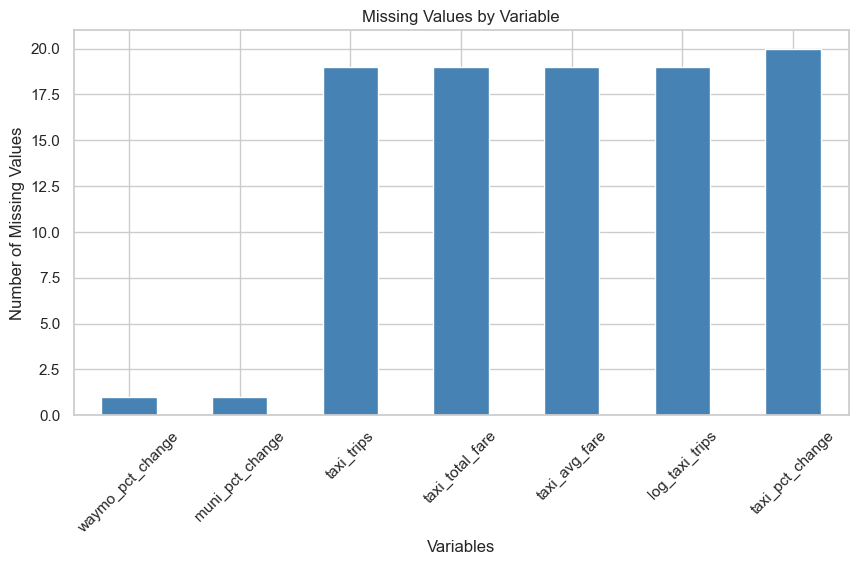

In [7]:
missing = df.isnull().sum()

plt.figure(figsize=(10,5))

missing[missing > 0].sort_values().plot(
    kind="bar",
    color="steelblue"
)

plt.title("Missing Values by Variable")
plt.ylabel("Number of Missing Values")
plt.xlabel("Variables")

plt.xticks(rotation=45)
plt.show()

Several taxi-related variables contain missing values because the available taxi dataset covers only part of the study period.

Most transportation variables, including Waymo passenger miles, Muni ridership, and SFO ground transportation activity, contain complete observations.

The missing values are concentrated in taxi-related variables and percentage-change measures derived from those variables.

# Waymo Growth Over Time

This figure shows monthly Waymo passenger miles from January 2023 to December 2025.

The red dashed line marks Waymo's public launch in August 2023.
The green dashed line marks the expansion to all riders in June 2024.

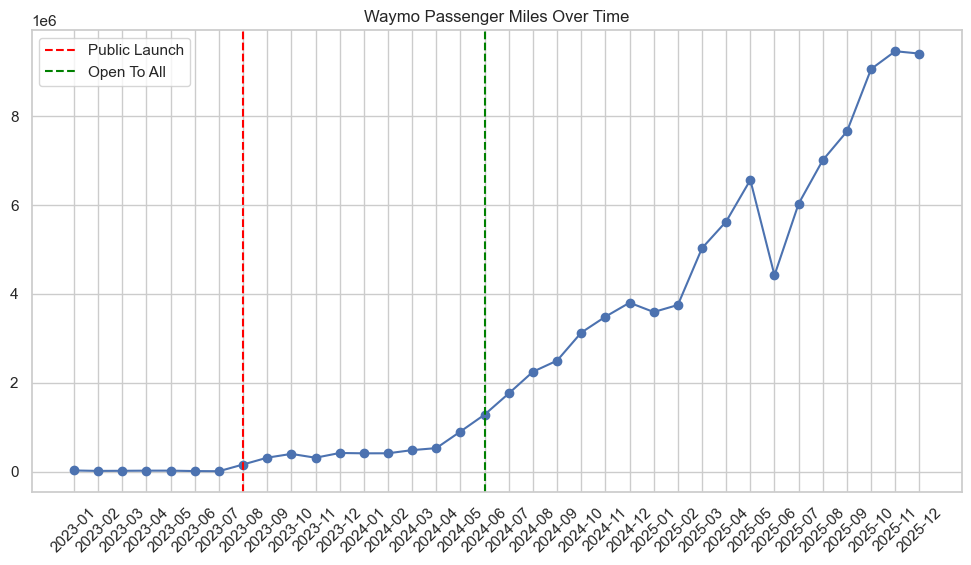

In [8]:
plt.figure(figsize=(12,6))

plt.plot(
    df["month"],
    df["waymo_passenger_miles"],
    marker="o"
)

plt.axvline(
    x="2023-08",
    linestyle="--",
    color="red",
    label="Public Launch"
)

plt.axvline(
    x="2024-06",
    linestyle="--",
    color="green",
    label="Open To All"
)

plt.legend()

plt.title("Waymo Passenger Miles Over Time")

plt.xticks(rotation=45)

plt.show()

## Observation

Waymo passenger miles remained very low during the first half of 2023.

After the August 2023 public launch, passenger miles increased steadily.

Growth accelerated further after the June 2024 expansion, suggesting that broader service availability was associated with substantial increases in Waymo usage.

By late 2025, passenger miles exceeded 9 million per month, indicating rapid adoption of autonomous ride-hailing services.

# Taxi Activity Over Time

This figure displays monthly taxi trip counts in San Francisco from January 2023 to May 2024.

The red dashed line indicates Waymo's public launch in August 2023.

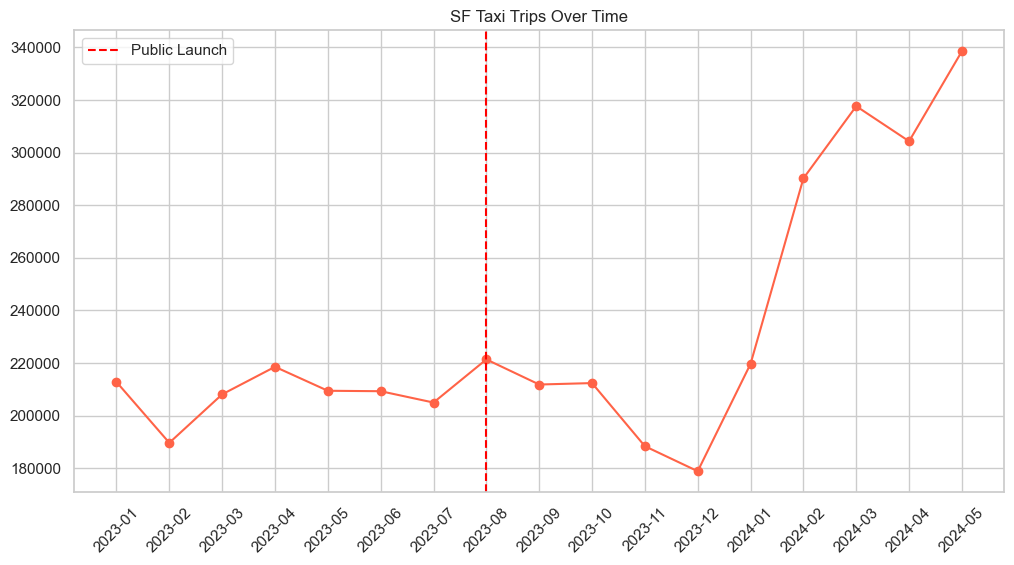

In [9]:
plt.figure(figsize=(12,6))

taxi_df = df[df["taxi_trips"].notna()]

plt.plot(
    taxi_df["month"],
    taxi_df["taxi_trips"],
    marker="o",
    color="tomato"
)

plt.axvline(
    x="2023-08",
    linestyle="--",
    color="red",
    label="Public Launch"
)

plt.legend()

plt.title("SF Taxi Trips Over Time")

plt.xticks(rotation=45)

plt.show()

## Observation

Taxi trip counts remained relatively stable throughout most of 2023, fluctuating between approximately 190,000 and 220,000 trips per month.

After Waymo's public launch in August 2023, there is no clear visual evidence of an immediate decline in taxi activity following Waymo's public launch. Instead, taxi trips increased substantially during the first half of 2024.

However, taxi data are only available through May 2024. Because the dataset does not include the period after Waymo became fully available to all riders in June 2024, the long-term relationship between Waymo expansion and taxi demand cannot be directly evaluated from this dataset.

Further analysis is required to determine whether Waymo growth is associated with reductions in taxi usage.

# Waymo and Taxi Activity Over Time

This figure compares monthly Waymo passenger miles and San Francisco taxi trips over time.

The red dashed line indicates Waymo's public launch in August 2023.

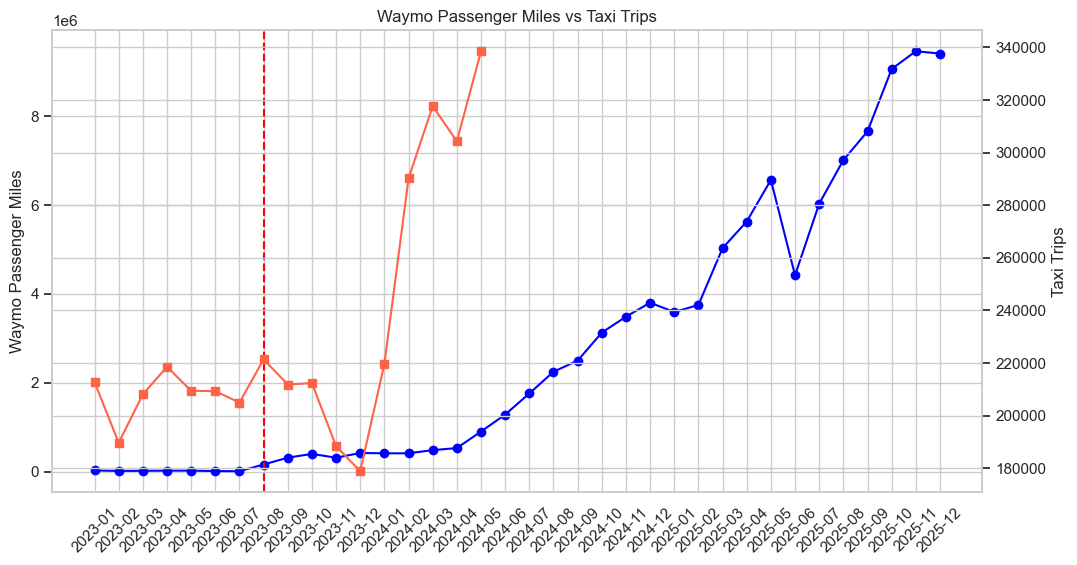

In [10]:
fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(
    df["month"],
    df["waymo_passenger_miles"],
    marker="o",
    color="blue",
    label="Waymo Passenger Miles"
)

ax1.set_ylabel("Waymo Passenger Miles")

ax2 = ax1.twinx()

taxi_df = df[df["taxi_trips"].notna()]

ax2.plot(
    taxi_df["month"],
    taxi_df["taxi_trips"],
    marker="s",
    color="tomato",
    label="Taxi Trips"
)

ax2.set_ylabel("Taxi Trips")

ax1.axvline(
    x="2023-08",
    linestyle="--",
    color="red",
    label="Public Launch"
)

plt.title("Waymo Passenger Miles vs Taxi Trips")

ax1.tick_params(axis="x", rotation=45)

plt.show()

## Observation

Waymo passenger miles increased dramatically following the public launch in August 2023 and continued to grow throughout the study period.

Taxi trip counts remained relatively stable during late 2023 and then increased substantially during the first half of 2024. During the period where both datasets overlap, there is no clear visual evidence that increases in Waymo activity corresponded to decreases in taxi demand.

Instead, both Waymo passenger miles and taxi trips increased simultaneously between January and May 2024. One possible explanation is that Waymo expanded alongside existing transportation services rather than immediately replacing traditional taxi demand.

However, taxi data are only available through May 2024. Therefore, the long-term impact of Waymo's June 2024 expansion to all riders cannot be directly evaluated using the available taxi dataset.

# Muni Ridership Over Time

This figure shows monthly Muni ridership from January 2023 to December 2025.

The red dashed line indicates Waymo's public launch in August 2023.

The green dashed line indicates Waymo's expansion to all riders in June 2024.

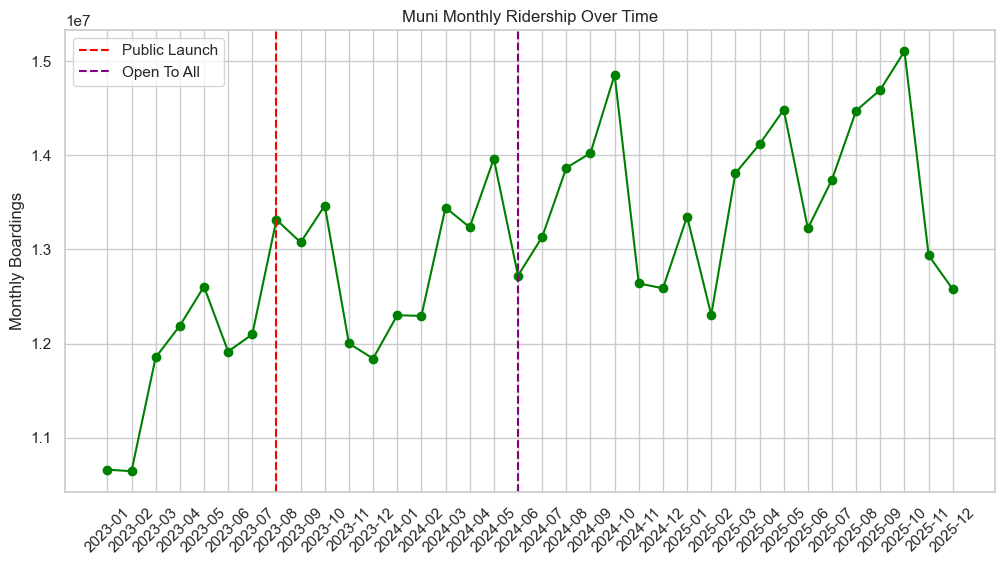

In [11]:
plt.figure(figsize=(12,6))

plt.plot(
    df["month"],
    df["muni_monthly_boardings"],
    marker="o",
    color="green"
)

plt.axvline(
    x="2023-08",
    linestyle="--",
    color="red",
    label="Public Launch"
)

plt.axvline(
    x="2024-06",
    linestyle="--",
    color="purple",
    label="Open To All"
)

plt.legend()

plt.title("Muni Monthly Ridership Over Time")

plt.ylabel("Monthly Boardings")

plt.xticks(rotation=45)

plt.show()

## Observation

Muni ridership generally increased between 2023 and 2025, despite month-to-month fluctuations.

Following Waymo's public launch in August 2023, Muni boardings continued to grow rather than decline. Ridership also remained relatively strong after Waymo expanded service to all riders in June 2024.

The highest ridership levels occurred during late 2024 and throughout much of 2025, suggesting that increased Waymo usage did not coincide with an immediate reduction in public transit demand.

These results provide preliminary evidence that Waymo and Muni may have served different transportation needs during the study period.

# Correlation Analysis

This heatmap summarizes pairwise correlations among the major transportation variables.

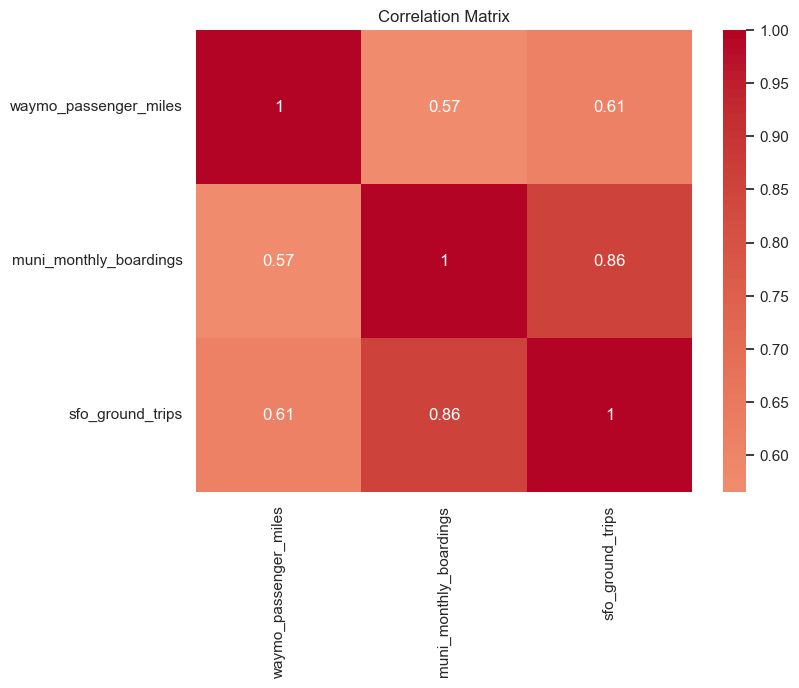

In [12]:
corr_vars = [
    "waymo_passenger_miles",
    "muni_monthly_boardings",
    "sfo_ground_trips"
]

corr_df = df[corr_vars].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_df,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

### Observation

The correlation matrix shows positive relationships among all three transportation variables.

Muni ridership and SFO ground transportation activity exhibit the strongest correlation (r ≈ 0.86).

Waymo passenger miles are moderately correlated with both Muni ridership (r ≈ 0.57) and SFO ground transportation activity (r ≈ 0.61).

These results suggest that transportation activity generally increased across multiple modes during the study period.

# Waymo Passenger Miles vs Muni Ridership

This scatter plot examines the relationship between Waymo passenger miles and Muni monthly ridership.

The fitted regression line provides a visual indication of whether increases in Waymo activity are associated with changes in public transit usage.

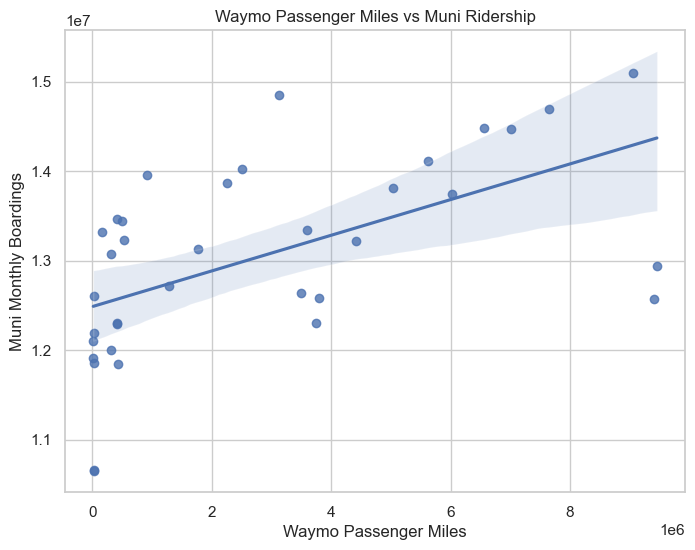

In [13]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="waymo_passenger_miles",
    y="muni_monthly_boardings"
)

plt.title("Waymo Passenger Miles vs Muni Ridership")

plt.xlabel("Waymo Passenger Miles")
plt.ylabel("Muni Monthly Boardings")

plt.show()

## Observation

The scatter plot shows a moderate positive relationship between Waymo passenger miles and Muni ridership.

As Waymo passenger miles increased, Muni ridership also tended to increase. This result is consistent with the correlation coefficient of approximately 0.57 shown in the correlation matrix.

Rather than indicating direct competition, the positive relationship suggests that Waymo growth and public transit ridership may have increased simultaneously during the study period. Both services may have benefited from broader recovery in travel demand and economic activity in San Francisco.

Further statistical analysis would be required to determine whether Waymo directly affected public transit usage. Correlation does not imply causation, and additional regression analysis is required to evaluate potential causal relationships.

## EDA Summary

Overall, Waymo passenger activity increased substantially between 2023 and 2025.

The exploratory analysis does not provide evidence that Waymo's expansion immediately reduced taxi demand or public transit ridership.

Instead, multiple transportation indicators increased simultaneously during the study period, suggesting that broader transportation demand growth may have influenced these trends.

These findings motivate the regression analyses presented in the following notebook.